# Análisis de Landmarks Faciales Aplicando t-SNE e Isomap
### Por: Israel Juarez Jimenez y Tiffany Martinez Paredes 
Este notebook presenta el proceso para extraer y analizar puntos faciales (landmarks) desde un conjunto de datos de imágenes faciales, utilizando técnicas de reducción de dimensionalidad como t-SNE e Isomap para visualizar la distribución de las emociones asociadas.

## Importación de Librerías

In [14]:
import os
import re
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import dlib
from sklearn.manifold import TSNE, Isomap


## Función para Leer Datos desde Archivos `.txt`

La función `leer_datos` se encarga de recorrer una estructura de directorios a partir de la ruta base proporcionada, para extraer las rutas de las imágenes faciales y las emociones correspondientes almacenadas en archivos `.txt`. El proceso incluye los siguientes pasos:

1. **Recorrido del Directorio**: La función usa `os.walk` para recorrer todos los subdirectorios y archivos en la estructura de carpetas. Esto permite explorar recursivamente los directorios y obtener todos los archivos `.txt` que contienen los valores de las emociones.

2. **Filtrado de Carpetas y Archivos**: Se excluyen carpetas no relevantes (por ejemplo, carpetas ocultas) y archivos que no sean de interés, asegurando que solo se procesen los archivos `.txt`.

3. **Ordenamiento de Archivos y Directorios**: Para facilitar la correspondencia entre archivos, tanto los subdirectorios como los archivos se ordenan numéricamente utilizando una función auxiliar `ordenar_numerico`, lo que asegura que las imágenes se procesen en el orden esperado.

4. **Extracción del Valor de Emoción**: Para cada archivo `.txt`, se lee el contenido (presumiblemente un número que indica la clase de emoción) y se intenta convertir a un número entero. Si la conversión falla, se reporta un error pero el procesamiento continúa con los siguientes archivos.

5. **Construcción de la Ruta de la Imagen Asociada**: Se determina la ruta relativa de la imagen facial correspondiente a partir del directorio de la emoción, y se buscan archivos de imagen (con extensión `.png`) en ese subdirectorio.

6. **Selección de la Última Imagen del Directorio**: Si se encuentran múltiples imágenes en el directorio, se selecciona la última imagen, asumiendo que esta representa la última etapa de la secuencia de expresión facial.

7. **Agregado de la Ruta de la Imagen y el Valor de la Emoción a la Lista de Datos**: La función devuelve una lista de tuplas, donde cada tupla contiene la ruta de la imagen y su emoción asociada.


In [15]:
def ordenar_numerico(valor):
    # Ordenar cadenas numéricamente
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes
    
def leer_datos(ruta_base):
    datos = [] # lista para almacenar pares de (ruta de imagen, emoción)
    
    for dir_act, subdirs, archivos in os.walk(ruta_base): # recorrer los directorios
         
        subdirs[:] = [d for d in subdirs if not d.startswith('.')] # filtrar subdirectorios para excluir carpetas ocultas
        archivos = [f for f in archivos if not f.startswith('.')] # filtrar archivos para excluir archivos no relevantes 
        
        # Ordenar subdirectorios y archivos 
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)


        for arch in archivos:   
            if arch.endswith('.txt'): # Procesar solo archivos con la extensión .txt
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    # Intentar abrir el archivo y leer el valor de la emoción
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip() 
                    try:
                        valor = int(float(valor))  
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    # Determinar la ruta relativa del directorio de la imagen en función del archivo de emoción
                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel) # ruta del directorio donde se espera encontrar las imágenes
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]  # Listar todos los archivos filtrando solo aquellos con extensión .png
                    imgs.sort(key=ordenar_numerico)  # Ordenar los nombres de las imágenes numéricamente
                    
               
                    if imgs:
                        ruta_img = os.path.join(dir_img, imgs[-1]) # Seleccionar la última imagen en el directorio(maxima expresión)                     
                        datos.append((ruta_img, valor)) # Añadir la ruta de la imagen y el valor de la emoción a la lista de datos
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    
    # Retornar la lista de(ruta de imagen, emoción)
    return datos


## Configuración del Detector de Rostros y el Predictor de Landmarks
Se utiliza dlib para detectar rostros y predecir puntos faciales en las imágenes. Es necesario tener el archivo shape_predictor_68_face_landmarks.dat para predecir correctamente los 68 puntos faciales.

In [16]:
# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")


## Función para Centrar los Puntos Faciales

La función centrar_pts ajusta los puntos faciales de manera que el punto correspondiente a la nariz (índice 30) se encuentre en el origen.

In [17]:
def centrar_pts(pts):
    # Centrar puntos faciales usando la nariz como referencia
    nariz = pts[30]  # El índice 30 corresponde a la nariz
    pts_centrados = [(x - nariz[0], y - nariz[1]) for x, y in pts]
    return pts_centrados


## Extracción de Landmarks y Emociones

La función `extraer_landmarks` toma como entrada una lista de datos que contienen la ruta de la imagen facial y el valor asociado a la emoción. El propósito de esta función es procesar esas imágenes para extraer los puntos faciales (landmarks) y las emociones correspondientes. La función sigue los siguientes pasos:

1. **Inicialización de Listas de Resultados**: Se crean dos listas vacías para almacenar los landmarks (puntos faciales) y las emociones.

2. **Iteración sobre los Datos de Entrada**: La función recorre cada elemento de la lista de datos proporcionada, donde cada elemento es una tupla que contiene la ruta de la imagen y el valor de la emoción.

3. **Validación del Formato de los Datos**: Si el elemento no tiene el formato esperado (una tupla de dos elementos), se ignora y se informa al usuario.

4. **Extracción de Puntos Faciales (Landmarks)**: 
   - La función intenta extraer los puntos faciales usando la función `extraer_puntos`, que se supone obtiene los 68 landmarks de la imagen.
   - Si la extracción es exitosa y el número de puntos obtenidos es exactamente 68, los puntos se centran utilizando la función `centrar_pts`, la cual ajusta los puntos para que la nariz esté en el origen del sistema de coordenadas.

5. **Almacenamiento de los Resultados Válidos**: 
   - Si los puntos centrados son válidos, se agregan a la lista de landmarks, y la emoción correspondiente se añade a la lista de emociones.
   - Si no se detectan los 68 puntos faciales requeridos, se informa al usuario y se ignora el elemento.

6. **Conversión de Resultados a Formatos Adecuados**:
   - Las listas de puntos faciales y emociones se convierten a un tensor de PyTorch (`tensor_pts`) y a un array de NumPy (`array_emo`), respectivamente, para facilitar su uso en operaciones posteriores.

7. **Retorno de los Resultados**: Si no se extrajeron puntos faciales válidos de ninguna imagen, la función devuelve `None` para ambos resultados. En caso contrario, retorna el tensor de landmarks y el array de emociones.


In [18]:
def extraer_puntos(ruta_imagen):
    # Extraer puntos faciales de una imagen
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos

def extraer_landmarks(datos):
   
    lista_pts = [] # listas para  los puntos faciales 
    lista_emo = [] # lista para  las emociones 

    for item in datos:
        if len(item) != 2: # Verificar que sea una tupla de longitud 2
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img, emo = item  # Desempaquetar la tupla en la ruta de la imagen y el valor de la emoción
        pts = extraer_puntos(ruta_img)  # extraer los puntos faciales de la imagen

        if pts is not None and len(pts) == 68:
            pts_centrados = centrar_pts(pts)  # centrar los puntos faciales alrededor de la nariz
            lista_pts.append(pts_centrados) # añadir los puntos centrados a la lista de landmarks
            lista_emo.append(emo) # añadir el valor de la emoción a la lista de emociones
        else:
            print(f"No se detectaron 68 puntos faciales en la imagen {ruta_img}")

    if not lista_pts:
        print("No se extrajeron puntos faciales.")
        return None, None

    # convertir las listas a un tensor de PyTorch y un array de NumPy para su procesamiento posterior
    tensor_pts = torch.tensor(lista_pts, dtype=torch.float32)
    array_emo = np.array(lista_emo)

    # Retornar el tensor de landmarks y el array de emociones
    return tensor_pts, array_emo


## Aplicación de Reducción de Dimensionalidad

La función `reducir_dim` transforma los landmarks faciales a un espacio de menor dimensionalidad, aplicando dos técnicas de reducción de dimensionalidad: t-SNE e Isomap. La reducción de dimensionalidad es especialmente útil para visualizar datos complejos en dos dimensiones, lo que facilita la identificación de patrones o agrupaciones en los datos.

### Pasos de la Función

1. **Conversión del Tensor a Numpy**: El tensor de PyTorch que contiene los landmarks faciales es convertido a un array de NumPy. Esta conversión permite utilizar las funciones de la biblioteca `scikit-learn`, que requiere que los datos estén en formato NumPy. Los landmarks son reorganizados en una matriz bidimensional con una fila por cada muestra y una columna por cada coordenada de los puntos.

2. **Aplicación de t-SNE**:
   - t-SNE (t-Distributed Stochastic Neighbor Embedding) es una técnica no lineal de reducción de dimensionalidad que intenta conservar las relaciones de distancia entre los puntos de datos. Es particularmente eficaz para la visualización en espacios de dos o tres dimensiones.
   - La función crea una instancia del modelo t-SNE configurado para reducir los datos a dos dimensiones (`n_components=2`) y aplica el algoritmo a los datos de entrada.

3. **Aplicación de Isomap**:
   - Isomap es otra técnica de reducción de dimensionalidad que conserva las distancias geodésicas entre los puntos en un espacio no lineal, proporcionando una representación en un espacio de menor dimensión.
   - El algoritmo Isomap también se configura para reducir los datos a dos dimensiones.

4. **Retorno de los Resultados**: La función retorna los resultados de t-SNE e Isomap, los cuales son matrices bidimensionales con la representación reducida de los landmarks.


In [19]:
def reducir_dim(tensor_pts):
    # El reshape asegura que cada fila representa una muestra con todas sus coordenadas 
    pts_np = tensor_pts.numpy().reshape(len(tensor_pts), -1)

    # n_components=2 indica que queremos reducir a dos dimensiones para la visualización
    
    # aplicar t-SNE para reducir la dimensionalidad a 2D
    # random_state=42 establece una semilla para la aleatoriedad
    tsne = TSNE(n_components=2, random_state=42)
    tsne_res = tsne.fit_transform(pts_np)

    # Aplicar Isomap para una reducción de dimensionalidad alternativa
    isomap = Isomap(n_components=2)
    isomap_res = isomap.fit_transform(pts_np)

    # Retornar los resultados de t-SNE e Isomap
    # Cada resultado es una matriz con tantas filas como muestras originales y dos columnas que representan
    # las coordenadas en el nuevo espacio reducido
    return tsne_res, isomap_res


## Visualización de los Resultados

La función `graficar_res` se encarga de mostrar los resultados de las reducciones de dimensionalidad aplicadas mediante t-SNE e Isomap. La visualización en gráficos bidimensionales permite observar cómo se agrupan los datos (landmarks faciales) según las emociones, representadas mediante colores.

### Pasos de la Función

1. **Configuración del Mapa de Colores**:
   - Se utiliza una paleta de colores (`tab10`) que admite hasta 10 colores diferentes, adecuada para representar múltiples clases de emociones. La longitud del mapa de colores se ajusta según el número de emociones únicas presentes en el array de emociones (`array_emo`).

2. **Configuración del Lienzo de la Gráfica**:
   - Se crea una figura de tamaño `12x6` para que los dos gráficos (t-SNE e Isomap) puedan mostrarse uno al lado del otro.

3. **Visualización de t-SNE**:
   - Se muestra un gráfico de dispersión donde las dos primeras columnas de `tsne_res` representan las coordenadas bidimensionales obtenidas de la reducción con t-SNE.
   - Los colores de los puntos se establecen según los valores en `array_emo`, de forma que diferentes emociones tengan colores distintos.
   - Se añade una barra de color (`colorbar`) que muestra las etiquetas de las emociones, permitiendo identificar visualmente a qué emoción corresponde cada color.
   - La cuadrícula, títulos y etiquetas de los ejes se configuran para mejorar la legibilidad.

4. **Visualización de Isomap**:
   - De manera similar a t-SNE, se grafica un diagrama de dispersión usando las dos primeras columnas de `isomap_res`.
   - Se mantiene la misma configuración de colores, barras de color y estilo de gráficos para que la comparación visual sea consistente.

5. **Ajuste de la Disposición y Mostrado del Gráfico**:
   - `plt.tight_layout()` ajusta el espaciado entre los subgráficos para evitar solapamientos.
   - Finalmente, se muestra la gráfica completa con `plt.show()`.


In [20]:
def graficar_res(tsne_res, isomap_res, array_emo):
    # Crear un mapa de colores basado en el número de emociones únicas
    cmap = plt.get_cmap('tab10', len(np.unique(array_emo)))

    # Crear una figura para los gráficos de t-SNE e Isomap
    plt.figure(figsize=(12, 6))  

    # Graficar los resultados de t-SNE en la primera subparcela
    plt.subplot(1, 2, 1) 
    plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=array_emo, cmap=cmap, edgecolor='k', s=50)
    plt.colorbar(ticks=np.unique(array_emo), label='Emoción')  
    plt.title('t-SNE')  
    plt.xlabel('Componente 1')  
    plt.ylabel('Componente 2')  
    plt.grid(True, linestyle='--', alpha=0.6)  # Agregar una cuadrícula con línea discontinua

    # Graficar los resultados de Isomap en la segunda subparcela
    plt.subplot(1, 2, 2)  
    plt.scatter(isomap_res[:, 0], isomap_res[:, 1], c=array_emo, cmap=cmap, edgecolor='k', s=50)
    plt.colorbar(ticks=np.unique(array_emo), label='Emoción')
    plt.title('Isomap')  
    plt.xlabel('Componente 1')  
    plt.ylabel('Componente 2')  
    plt.grid(True, linestyle='--', alpha=0.6)  

    # Ajustar el diseño para evitar que los gráficos se superpongan
    plt.tight_layout()
    plt.show()

## Ejecución Completa del Flujo
El siguiente bloque de código ejecuta todo el flujo de procesamiento: lectura de datos, extracción de landmarks, reducción de dimensionalidad y visualización.

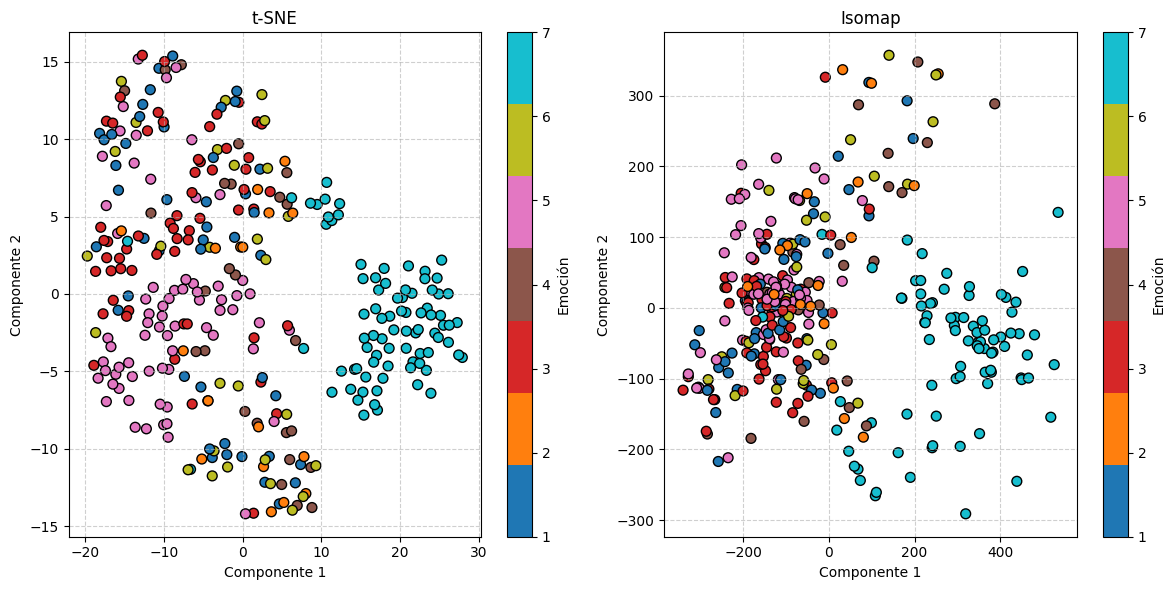

Clasificación de Emociones:
------------------------------
1: Enojo
2: Desprecio
3: Disgusto
4: Miedo
5: Felicidad
6: Tristeza
7: Sorpresa


In [21]:
dir_emo = "Emotion"
datos = leer_datos(dir_emo)

if datos:
    tensor_pts, array_emo = extraer_landmarks(datos)

    if tensor_pts is not None and array_emo is not None:
        # Aplicar t-SNE e Isomap
        tsne_res, isomap_res = reducir_dim(tensor_pts)

        # Visualizar los resultados
        graficar_res(tsne_res, isomap_res, array_emo)
        # Diccionario de emociones
        emociones = {
            1: 'Enojo',
            2: 'Desprecio',
            3: 'Disgusto',
            4: 'Miedo',
            5: 'Felicidad',
            6: 'Tristeza',
            7: 'Sorpresa'
        }
        
        # Imprimir el diccionario 
        print("Clasificación de Emociones:\n" + "-"*30)
        for clave, valor in emociones.items():
            print(f"{clave}: {valor}")
    else:
        print("No se pudo aplicar t-SNE e Isomap debido a falta de datos.")
else:
    print("No se encontraron datos de emociones para procesar.")


## Análisis Comparativo de las Gráficas: t-SNE vs. Isomap

Las gráficas muestran la reducción de dimensionalidad en datos de emociones faciales con t-SNE e Isomap, facilitando el análisis de patrones. A continuación, se destacan los puntos clave.

### 1. Evaluación General de la Distribución

t-SNE: Muestra agrupaciones claras, especialmente para Felicidad (5) y Sorpresa (7), indicando que captura la estructura local eficazmente. Las emociones negativas (Enojo, Disgusto, Miedo) presentan cierta superposición.

Isomap: Presenta mayor dispersión y mezcla entre clases, lo que dificulta la identificación de patrones específicos. Sin embargo, preserva mejor la estructura global.

### 2. Análisis de Agrupamiento por Clases Específicas

- **Agrupamiento en t-SNE**:
    - La técnica de t-SNE muestra una separación más clara para ciertas clases de emociones. Por ejemplo, la emoción de Felicidad (5) y Sorpresa (7) presentan agrupaciones más compactas, lo que indica que estas clases son más fácilmente distinguibles en el espacio de características.
    - Las emociones negativas como Enojo (1), Disgusto (3) y Miedo (4) presentan cierta superposición, lo que podría deberse a que comparten características faciales similares, dificultando la separación completa en el espacio reducido.

- **Agrupamiento en Isomap**:
    - En comparación, Isomap muestra una mayor superposición entre las clases, con emociones como Disgusto (3), Tristeza (6) y Miedo (4) dispersas en un área común. Esto sugiere que Isomap no logra separar adecuadamente estas clases debido a la similitud global de sus características en el conjunto de datos.
    - Las emociones más distintivas, como Felicidad (5) y Sorpresa (7), todavía se pueden identificar, pero con una separación menos marcada que en t-SNE.

### 3. Evaluación de la Dispersión de los Datos

- **Dispersión en t-SNE**:
    - La dispersión es más controlada y las agrupaciones son más compactas, lo que refleja que t-SNE ha preservado las relaciones locales entre los puntos. Los datos similares en el espacio original permanecen juntos en la representación bidimensional, lo cual es ideal para detectar grupos o clústeres naturales en los datos.

- **Dispersión en Isomap**:
    - La dispersión en Isomap es significativamente mayor, con algunos puntos alejados del centro del grupo principal. Esto podría indicar la presencia de outliers o puntos que no se ajustan bien a la estructura general de los datos. La técnica tiende a capturar la estructura global, pero esto puede causar una mayor dispersión en la visualización.

### 4. Impacto de la Técnica de Reducción de Dimensionalidad
- **t-SNE**: Adecuado para identificar patrones locales y clústeres.

- **Isomap**: Mejor para relaciones globales, pero menos efectivo en distinguir grupos específicos.

### Conclusiones

- **t-SNE ofrece una mejor visualización para la separación de clases de emociones** debido a su capacidad para preservar la estructura local de los datos. Es la opción preferida si el objetivo es la identificación de clústeres y la diferenciación entre emociones con características faciales distintivas.
- **Isomap proporciona una perspectiva más global**, pero la falta de separación clara entre las clases indica que podría no ser la técnica más adecuada para este conjunto de datos específico, a menos que se ajuste adecuadamente el número de vecinos.

